# Laboratorio Modelos Probabilísticos de Difusión para Reducción de Ruido (DDPMs)

En este laboratorio exploraremos la generación de imágenes utilizando un modelo Probabilístico de Difusión para Reducción de Ruido (DDPM) entrenado con el dataset MNIST Fashion. A lo largo del ejercicio, construiremos y entrenaremos un modelo DDPM, evidenciando cómo las técnicas de difusión pueden generar imágenes realistas a partir de ruido gaussiano. Además, experimentaremos con distintos hiperparámetros del modelo para observar cómo estos ajustes afectan el proceso de aprendizaje y la calidad de las imágenes generadas, llevando lo aprendido en las clases teóricas a la práctica. El objetivo principal de este laboratorio es observar en la práctica cómo se da el proceso de difusión y comprender el impacto de algunos de sus parámetros en el rendimiento del modelo, mejorando o empeorando los resultados finales.

### Primero ingresa tu código uniandes

In [1]:
codigo = 202422619

## 1. Preparación del entorno
Primero, importaremos las librerías necesarias para implementar y entrenar nuestro modelo de difusión. Estas librerías incluyen herramientas esenciales para manipular datos, construir modelos neuronales y visualizar los resultados. A continuación, una breve descripción de algunas de estas librerías:

* `numpy`: La librería de manipulación de arrays que facilita cálculos numéricos eficientes, como la creación de matrices y operaciones matemáticas.
* `torch`: La librería principal para crear modelos de aprendizaje profundo. Proporciona herramientas para construir y entrenar redes neuronales de manera eficiente, tanto en CPU como en GPU.
* `torch.utils.data (DataLoader)`: Facilita la carga de datos en lotes, lo que nos ayuda a alimentar las imágenes a nuestro modelo durante el entrenamiento.
* `torchvision.datasets (FashionMNIST)`: Nos proporciona la base de datos FashionMNIST, que contiene imágenes de ropa en escala de grises, usada para entrenar y evaluar nuestro modelo.

In [2]:
import random
import imageio
import numpy as np
from IPython.display import Image
import os

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import einops
import torch
import lm
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.transforms import Compose, ToTensor, Lambda, Resize
from torchvision.datasets.mnist import FashionMNIST

Establecemos semilla para reproducibilidad:

In [3]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Establecer dispositivo para correr experimentos

Configuramos el dispositivo en el cual vamos a entrenar nuestro modelo. Si tienes una GPU disponible, PyTorch la detectará y la utilizará para acelerar el proceso. De lo contrario, los experimentos se ejecutarán en la CPU, aunque con un tiempo de procesamiento mayor.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"Using device: {device}\t"
    + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU")
)

Using device: cuda	NVIDIA L4


## 3. Herramienta de visualización
Para visualizar tanto nuestras imágenes de entrenamiento como las imágenes generadas más adelante, usaremos la siguiente función.

In [5]:
def visualize_images(images, title=""): 

    if type(images) is torch.Tensor:
        images = images.detach().cpu().numpy()

    # Crear subplot en caso de visualizar múltiples imágenes
    fig = plt.figure(figsize=(8, 8))
    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)

    # Ubicar cada imagen en el subplot
    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx < len(images):
                ax = fig.add_subplot(rows, cols, idx + 1)
                ax.imshow(images[idx][0], cmap="gray")
                ax.axis("off")
                idx += 1
                
    fig.suptitle(title, fontsize=30)

    # Presentar y guardar imagen resultante
    plt.show()


## 4. Cargar dataset

El dataset que usaremos en este laboratorio es FashionMNIST, una base de datos ampliamente utilizada en la investigación de visión por computador. Esta base de datos contiene 60,000 imágenes de entrenamiento, todas en escala de grises y con una resolución de 28x28 píxeles. Las imágenes corresponden a 10 categorías diferentes de prendas de vestir, tales como camisetas, pantalones, vestidos, zapatos, entre otros. Cada imagen está asociada con una etiqueta que indica la clase de prenda a la que pertenece, lo que nos permitirá utilizarla para entrenar nuestro modelo de difusión.

El conjunto de datos es ideal para este laboratorio, ya que su simplicidad permite experimentar con técnicas avanzadas de generación de imágenes, como los modelos de difusión probabilística, sin requerir un procesamiento extenso de datos complejos.

Para poder trabajar correctamente con esta base de datos, es necesario realizar algunas transformaciones en las imágenes antes de utilizarlas en el modelo. Estas transformaciones preparan los datos de manera adecuada para el proceso de entrenamiento, y son las siguientes:

* **Conversión a tensores (ToTensor):** Esta transformación convierte las imágenes de formato PIL (imágenes de Python) a tensores de PyTorch, que son el formato necesario para poder procesar los datos en nuestro modelo. Al hacer esto, los valores de los píxeles se normalizan automáticamente a un rango de [0, 1].

* **Normalización (Lambda(lambda x: (x - 0.5) * 2)):** Dado que nuestra red DDPM predice el ruido que sigue una distribución normal, es importante normalizar las imágenes. Esto significa ajustar los valores de los píxeles del rango [0, 1] al rango [-1, 1]. Este cambio es crucial para que el modelo pueda operar bajo el supuesto de que las imágenes contienen ruido distribuido normalmente, lo cual facilita el entrenamiento del modelo de denoising.

* **Multiplicación de canales (Lambda(lambda x: x.repeat(3, 1, 1)):** Aunque las imágenes originales están en escala de grises (un solo canal), muchos modelos, incluyendo el nuestro, esperan imágenes con tres canales (similar a las imágenes RGB). Por lo tanto, replicamos el único canal de las imágenes de FashionMNIST para que tengan tres canales, sin cambiar la información visual.

* **Redimensionamiento (Resize((28, 28))):** Aunque las imágenes ya tienen un tamaño de 28x28 píxeles, incluimos esta transformación para asegurarnos de que todas las imágenes tengan el mismo tamaño, lo que es una buena práctica cuando trabajamos con redes neuronales, garantizando consistencia en los datos de entrada.

Estas transformaciones se aplican a todas las imágenes del dataset, y luego las cargamos en un DataLoader, que nos permite iterar sobre los datos en lotes durante el proceso de entrenamiento. Cada lote o batch contendrá 128 imágenes, lo que mejora la eficiencia del entrenamiento, y los datos serán mezclados aleatoriamente en cada época para garantizar que el modelo no aprenda un patrón específico de los datos.

In [6]:
transform = Compose([ToTensor(), Lambda(lambda x: (x - 0.5) * 2), Lambda(lambda x: x.repeat(3, 1, 1)), Resize((28, 28))])
dataset = FashionMNIST("./", train=True, transform=transform)
loader = DataLoader(dataset, batch_size = 128, shuffle=True)
img_shape = dataset[0][0].shape 

print(f"Tamaño de las imágenes cargadas y pre-procesadas: {img_shape}")

Tamaño de las imágenes cargadas y pre-procesadas: torch.Size([3, 28, 28])


### Visualizando imágenes del dataset

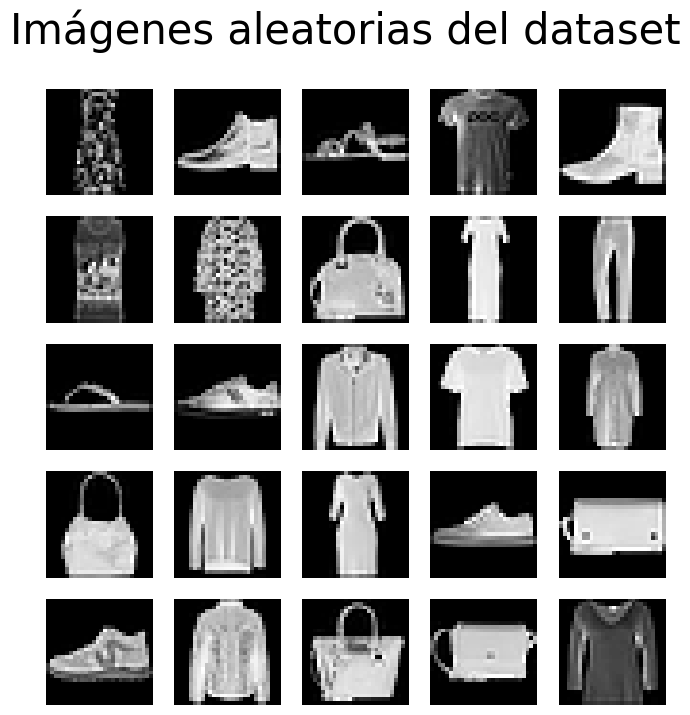

In [7]:
sample_batch = list(loader)[0][0][:25]
visualize_images(sample_batch, "Imágenes aleatorias del dataset")

## 5. Construcción de la red DDPM
El principio de los Modelos Probabilísticos de Difusión (DDPM) se basa en dos fases clave: la fase de difusión (forward) y la fase de denoising (backward). En este laboratorio, trabajaremos con una red UNet para predecir el ruido en las imágenes durante la fase backward.

* **Fase forward:** En esta fase, ruido gaussiano es añadido gradualmente a la imagen en varios pasos, hasta que la imagen original es irreconocible. Este proceso sigue una cadena de Markov, lo que significa que cada paso de difusión depende solo del paso anterior.

* **Fase backward:** En esta fase, el modelo de difusión trata de revertir el proceso de ruido utilizando la red UNet para predecir y eliminar el ruido añadido en cada paso.

* **Red de predicción de ruido (UNet):** La red UNet es una arquitectura popular en tareas de procesamiento de imágenes. En el contexto de una DDPM, se encarga de predecir el ruido que se debe eliminar en cada paso. La arquitectura de UNet incluye bloques convolucionales que realizan tanto el down-sampling (reducción de dimensiones para capturar patrones generales) como el up-sampling (recuperación de detalles). Nuestra UNet está compuesta por [X cantidad] de bloques convolucionales, lo que permite la predicción precisa del ruido en las imágenes.

* **Embeddings sinusoidales:** La UNet no se entrena con un modelo diferente para cada paso de denoising. En su lugar, se utiliza un único modelo que recibe como entrada tanto la imagen como un valor escalar que indica el paso de tiempo (t). Para mapear este paso de tiempo a una dimensión adecuada, usamos un embedding sinusoidal, que transforma cada timestep en un vector de embeddings con una dimensión específica. Este embedding de tiempo se propaga a través de la red UNet mediante MLPs (redes de capas lineales) que permiten incorporar el tiempo como una información relevante en las predicciones del modelo.

### 5.1. Red de predicción de ruido
En este laboratorio, utilizaremos una red UNet para predecir el ruido durante la fase backward de la DDPM. La UNet está compuesta por varios bloques convolucionales aplicados tanto en el proceso de **down-sampling** (para capturar características globales de la imagen) como en el de **up-sampling** (para reconstruir los detalles eliminando el ruido).

Por otra parte, el embedding de tiempo es crucial para que la red UNet pueda manejar múltiples pasos de denoising, y se incorpora a la red mediante embeddings sinusoidales que transforman el paso de tiempo t en un vector que la red puede entender y utilizar para mejorar sus predicciones de denoising o remoción de ruido.

Además, la UNet está diseñada de manera que los bloques convolucionales permiten que el modelo aprenda a reducir el ruido sin perder detalles clave de la imagen original. Esto se logra combinando capas de convolución, normalización y activación no lineal (SiLU).

In [8]:
def embedding_posicional(n, d):
    """Esta función crea un embedding sinusoidal que será usado para relacionar los pasos 
    o time-steps del proceso de difusión con su embedding de tiempo correspondiente"""
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)])
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    embedding[:, ::2] = torch.sin(t * wk[:, ::2])
    embedding[:, 1::2] = torch.cos(t * wk[:, ::2])

    return embedding

class UNetBlock(nn.Module):
    def __init__(
        self,
        shape,
        in_c,
        out_c,
        kernel_size=3,
        stride=1,
        padding=1,
        activation=None,
        normalize=True,
    ):
        super(UNetBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out
    
class UNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100, img_size=(1,28,28)):
        super(UNet, self).__init__()
        in_channels, in_height, in_width = img_size

        # Embedding correspondiente a los time-steps en la red
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = embedding_posicional(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # Primera fase de la UNet
        self.te1 = self.build_time_emb(time_emb_dim, 1)
        self.block1 = nn.Sequential(
            UNetBlock((in_channels, 28, 28), in_channels, 10),
            UNetBlock((10, 28, 28), 10, 10),
            UNetBlock((10, 28, 28), 10, 10),
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)

        self.te2 = self.build_time_emb(time_emb_dim, 10)
        self.block2 = nn.Sequential(
            UNetBlock((10, 14, 14), 10, 20),
            UNetBlock((20, 14, 14), 20, 20),
            UNetBlock((20, 14, 14), 20, 20),
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)

        self.te3 = self.build_time_emb(time_emb_dim, 20)
        self.block3 = nn.Sequential(
            UNetBlock((20, 7, 7), 20, 40),
            UNetBlock((40, 7, 7), 40, 40),
            UNetBlock((40, 7, 7), 40, 40),
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(40, 40, 2, 1), nn.SiLU(), nn.Conv2d(40, 40, 4, 2, 1)
        )

        # Bottleneck
        self.te_bottleneck = self.build_time_emb(time_emb_dim, 40)
        self.bottleneck_block = nn.Sequential(
            UNetBlock((40, 3, 3), 40, 20),
            UNetBlock((20, 3, 3), 20, 20),
            UNetBlock((20, 3, 3), 20, 40),
        )

        # Second half
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(40, 40, 4, 2, 1),
            nn.SiLU(),
            nn.ConvTranspose2d(40, 40, 2, 1),
        )

        self.te4 = self.build_time_emb(time_emb_dim, 80)
        self.block4 = nn.Sequential(
            UNetBlock((80, 7, 7), 80, 40),
            UNetBlock((40, 7, 7), 40, 20),
            UNetBlock((20, 7, 7), 20, 20),
        )

        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)
        self.te5 = self.build_time_emb(time_emb_dim, 40)
        self.block5 = nn.Sequential(
            UNetBlock((40, 14, 14), 40, 20),
            UNetBlock((20, 14, 14), 20, 10),
            UNetBlock((10, 14, 14), 10, 10),
        )

        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)
        self.te_out = self.build_time_emb(time_emb_dim, 20)
        self.b_out = nn.Sequential(
            UNetBlock((20, 28, 28), 20, 10),
            UNetBlock((10, 28, 28), 10, 10),
            UNetBlock((10, 28, 28), 10, 10, normalize=False),
        )

        self.conv_out = nn.Conv2d(10, in_channels, 3, 1, 1)

    def forward(self, x, t):
        # x tiene dimension (N, 2, 28, 28) donde N corresponde al batch size y la segunda dimensión contiene la imagen como tal y el embedding del tiempo t.
        t = self.time_embed(t)
        n = len(x)
        out1 = self.block1(x + self.te1(t).reshape(n, -1, 1, 1))  
        out2 = self.block2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  
        out3 = self.block3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1)) 

        out_bottleneck = self.bottleneck_block(self.down3(out3) + self.te_bottleneck(t).reshape(n, -1, 1, 1)) 

        out4 = torch.cat((out3, self.up1(out_bottleneck)), dim=1) 
        out4 = self.block4(out4 + self.te4(t).reshape(n, -1, 1, 1)) 
        out5 = torch.cat((out2, self.up2(out4)), dim=1) 
        out5 = self.block5(out5 + self.te5(t).reshape(n, -1, 1, 1))  
        out = torch.cat((out1, self.up3(out5)), dim=1)  
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))

        out = self.conv_out(out)
        return out

    def build_time_emb(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out), nn.SiLU(), nn.Linear(dim_out, dim_out)
        )
    

### 5.2. Proceso forward y backward de la red

Ya que hemos construido la red de predicción de ruido, podemos proceder a implementar el código que gestionará la adición y remoción de ruido aleatorio a las imágenes durante el proceso de difusión. En este punto, añadiremos ruido progresivamente a las imágenes originales durante la fase forward y entrenaremos nuestra red UNet para predecir y eliminar dicho ruido durante la fase backward.

La clase DDPMModel es la encargada de manejar ambos procesos, el de añadir ruido (forward) y el de predecirlo (backward). En la fase forward, el ruido es añadido a las imágenes basándose en los valores de **beta** que **definen la cantidad de ruido a inyectar en cada paso**. En la fase backward, la red UNet predice cuánto del ruido añadido puede ser removido para aproximarse a la imagen original.

In [9]:
# DDPM class
class DDPMModel(nn.Module):
    def __init__(
        self,
        network, # U-Net
        n_steps=200,
        min_beta=10**-4,
        max_beta=0.02,
        device=None,
        image_chw=(1, 28, 28),
    ):
        super(DDPMModel, self).__init__()
        self.n_steps = n_steps
        self.device = device
        self.image_chw = image_chw
        self.network = network.to(device)
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(
            device
        )  
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.tensor(
            [torch.prod(self.alphas[: i + 1]) for i in range(len(self.alphas))]
        ).to(device)

    def forward(self, x0, t, eta=None): 
        n, c, h, w = x0.shape
        a_bar = self.alpha_bars[t]

        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)

        noisy = (
            a_bar.sqrt().reshape(n, 1, 1, 1) * x0 # Fracción de la salida que corresponde a x0
            + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta # Fracción de la salida que corresponde a ruido
        )
        return noisy

    def backward(self, x, t):
        # La red, en este caso UNet, está encargada de predecir cuánto de la entrada corresponde a ruido que debe ser removido.
        return self.network(x, t)

### 5.3. Declaración de la red

Para declarar nuestra red, debemos establecer algunos parámetros clave que controlarán el comportamiento del modelo:

* `n_steps`: Este parámetro define el número total de pasos de denoising en el proceso de difusión. En este caso, lo fijamos en 1000 pasos. Un mayor número de pasos tiende a dar lugar a una mejor calidad de las imágenes generadas, ya que el ruido es eliminado de manera más gradual.

* `min_beta` y `max_beta`: Estos parámetros controlan la cantidad de ruido añadido en cada paso. `min_beta` corresponde al ruido más bajo que se añade en los primeros pasos, mientras que `max_beta` define la cantidad máxima de ruido que se inyecta en los últimos pasos. El valor de beta varía linealmente entre estos dos valores a lo largo de los n_steps.

Estos parámetros son importantes para equilibrar la cantidad de ruido que se añade y la capacidad del modelo para eliminarlo. Definimos el modelo DDPM con estos parámetros y lo preparamos para comenzar el entrenamiento.

In [10]:
n_steps = 1000
original_min_beta = 10**-4 
original_max_beta = 0.02 

ddpm = DDPMModel(
    UNet(n_steps, img_size=img_shape),
    n_steps=n_steps,
    min_beta=original_min_beta,
    max_beta=original_max_beta,
    device=device,
)

print(f"Cantidad de parámetros del modelo: {sum([p.numel() for p in ddpm.parameters()])}")

Cantidad de parámetros del modelo: 610350


# 6. Visualizar proceso de adición y remoción de ruido

A continuación visualizamos cómo van cambiando las imágenes al entrar en la red en el proceso de adición de ruido. Recuerda que al tratarse del proceso forward, donde solamente se está agregando ruido aleatorio a la imagen, este resultado no se ve alterado por el hecho de que la red no haya sido entrenada aún.

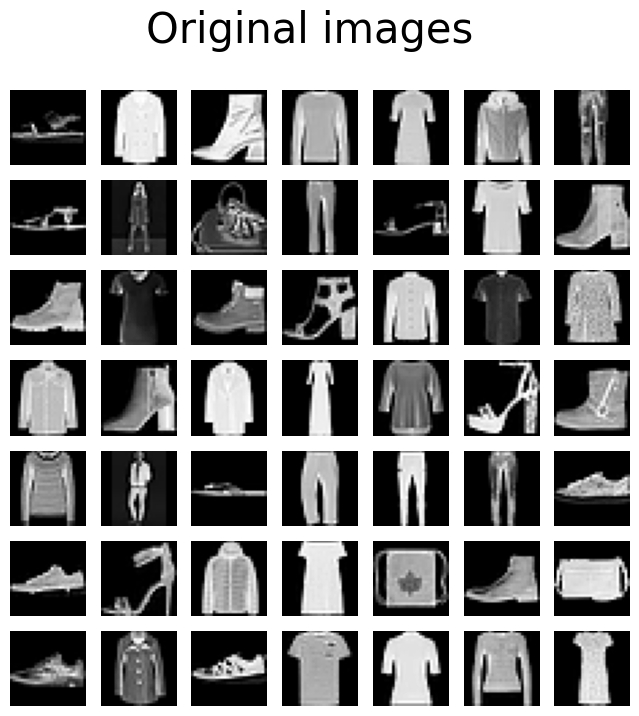

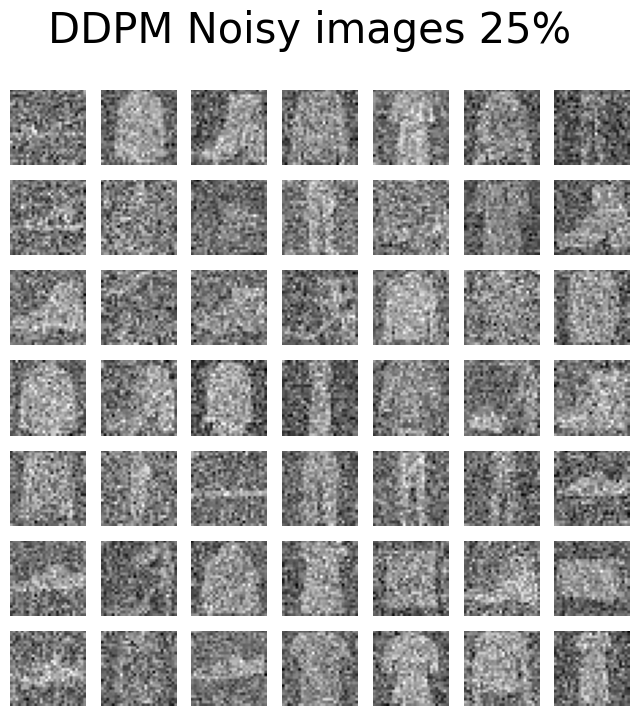

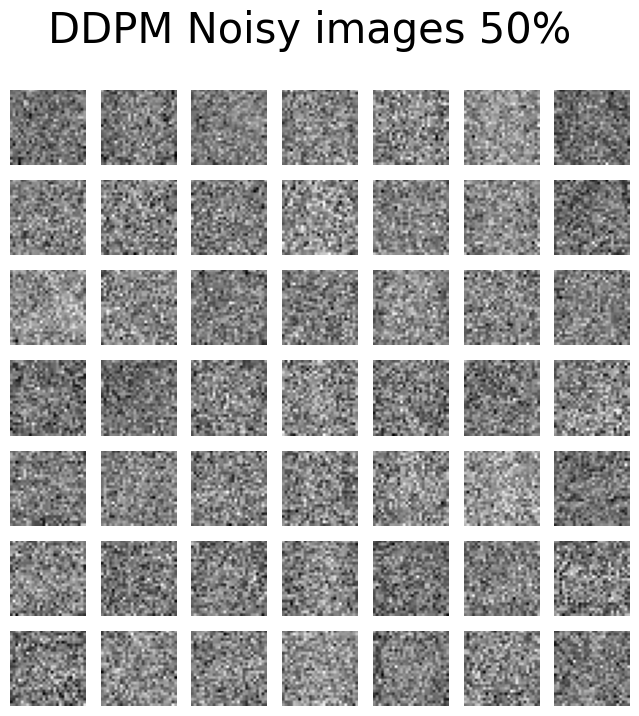

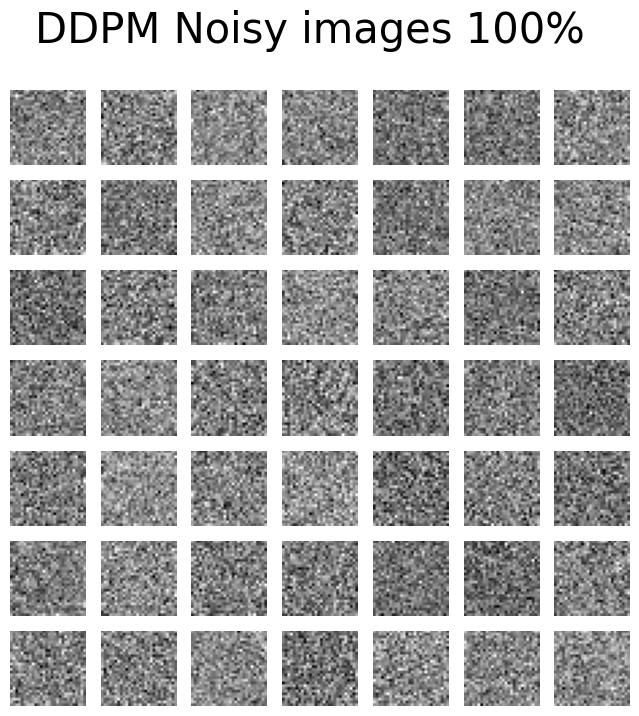

In [11]:
# Showing the forward process
imgs = list(loader)[0][0][:49]
visualize_images(imgs, "Original images")
for percent in [0.25, 0.5, 1]:
    visualize_images(
        ddpm(
            imgs.to(device),
            [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))],
        ),
        f"DDPM Noisy images {int(percent * 100)}%",
    )

Por otra parte, visualizamos el proceso de remoción de ruido. En este caso, la red -que aún no ha sido entrenada- debe en cada time step predecir la fracción de la imagen que corresponde a ruido para así removerlo y buscar obtener la imagen limpia. 

Para generar esta muestras creamos la función `generative_output`, la cual, además de obtener las imágenes generadas en cada time-step, crea un archivo .gif que permite visualizar la evolución del proceso backward en el tiempo.

In [12]:
def generate_output(
    ddpm,
    n_samples=16,
    device=None,
    frames_per_gif=100,
    gif_name="sampling.gif",
    img_size=(1,28,28),
):
    c, h, w = img_size
    
    frame_idxs = np.linspace(0, ddpm.n_steps, frames_per_gif).astype(np.uint)
    frames = []

    with torch.no_grad():
        if device is None:
            device = ddpm.device

        # Obtener ruido aleatorio inicial
        x = torch.randn(n_samples, c, h, w).to(device)

        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            # Predecir ruido que debe removerse
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)
            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            # Eliminación parcial del ruido
            x = (1 / alpha_t.sqrt()) * (
                x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta
            )

            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)

                beta_t = ddpm.betas[t]
                sigma_t = beta_t.sqrt()
                x = x + sigma_t * z

            # Acomodar los frames en el gif
            if idx in frame_idxs or t == 0:
                # Modificar rango de valores de las imágenes a [0, 255]
                normalized = x.clone()
                for i in range(len(normalized)):
                    normalized[i] -= torch.min(normalized[i])
                    normalized[i] *= 255 / torch.max(normalized[i])

                # Modificar forma de las imágenes para obtener frames cuadrados
                frame = einops.rearrange(
                    normalized,
                    "(b1 b2) c h w -> (b1 h) (b2 w) c",
                    b1=int(n_samples**0.5),
                )
                frame = frame.cpu().numpy().astype(np.uint8)
                frames.append(frame)

    # Guardar resultado en archivo gif
    with imageio.get_writer(gif_name, mode="I") as writer:
        for idx, frame in enumerate(frames):
            repeat_channels = 1 if c == 3 else 3
            rgb_frame = np.repeat(frame, repeat_channels, axis=2)
            writer.append_data(rgb_frame)

            if idx == len(frames) - 1:
                last_rgb_frame = np.repeat(frames[-1], repeat_channels, axis=2)
                for _ in range(frames_per_gif // 3):
                    writer.append_data(last_rgb_frame)
    return x

* Generación de muestras con **modelo no entrenado**:

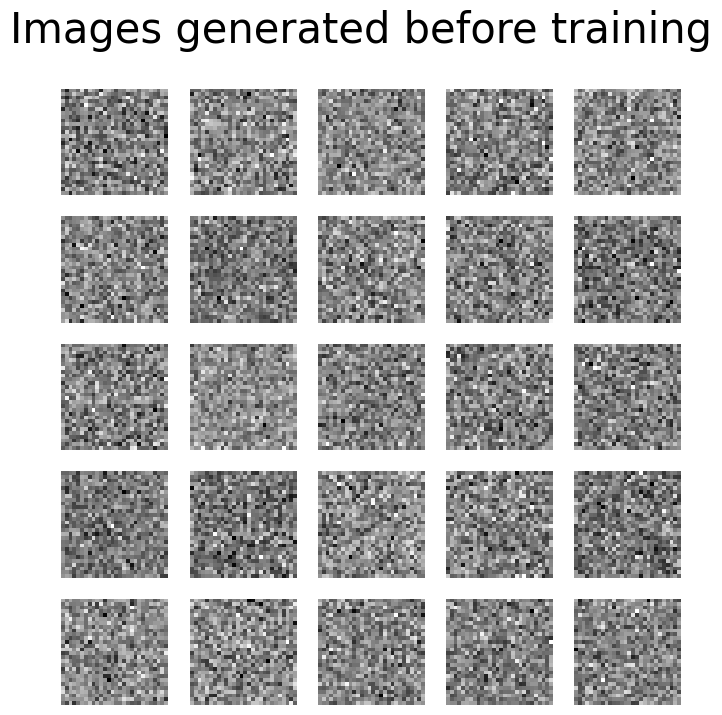

In [13]:
not_trained_outputs = generate_output(
    ddpm, 
    n_samples=25,
    gif_name="before_training.gif", 
    img_size=img_shape
    )

visualize_images(not_trained_outputs, "Images generated before training")

# 7. Entrenar modelo

A continuación, usaremos todas las funciones definidas previamente y el modelo declarado para realizar el entrenamiento de la red DDPM. Te invitamos a explorar distintos desempeños del proceso de entrenamiento camiando algunas de las variables, como el el número de **épocas de entrenamiento**, la **tasa de aprendizaje** o el **optimizador** del modelo.

En caso de que cuentes ya con el modelo entrenado, puedes saltarte el proceso de entrenamiento y generar imágenes nuevas más adelante.

In [14]:
store_path = "ddpm_model.pt"
total_epochs = 100
learning_rate = 0.001
optimizer = Adam(ddpm.parameters(), learning_rate)

In [15]:
# Definir función que realiza entrenamiento y retorna lista de losses del proceso.
def train_model(model, total_epochs, optimizer, store_path):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = model.n_steps

    total_losses = []
    for epoch in tqdm(range(total_epochs), desc=f"Training progress"):
        epoch_loss = 0.0
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{total_epochs}")):
            x0 = batch[0].to(device)
            n = len(x0)

            # Para cada image obtener ruido, un time-step y un valor alpha correspondiente
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)

            # Agregar ruido a las imágenes según el time-step que les corresponda (proceso forward)
            noisy_imgs = model(x0, t, eta)

            # Predecir ruido presente en la imagen (proceso backward)
            eta_theta = model.backward(noisy_imgs, t.reshape(n, -1))

            loss = mse(eta_theta, eta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)

        total_losses.append(epoch_loss)

        # Guardar modelo con mejor desempeño
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), store_path)
            log_string = f"Epoch {epoch + 1}: best model stored in {store_path} with loss of {epoch_loss:.3f}"
            print(log_string)

    # Graficar los valores de loss para ver si progreso
    plt.plot(total_losses, color="olive")
    plt.title('Progreso del loss en el entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.show()

    return total_losses

Training progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: best model stored in ddpm_model.pt with loss of 0.481


Epoch 2/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: best model stored in ddpm_model.pt with loss of 0.126


...

Epoch 98/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 99: best model stored in ddpm_model.pt with loss of 0.023


Epoch 100/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 100: best model stored in ddpm_model.pt with loss of 0.023


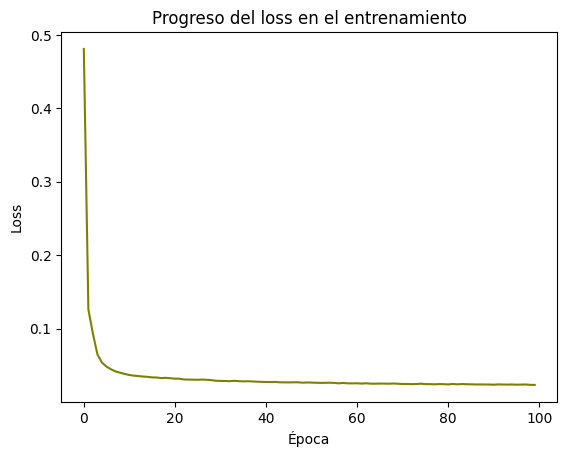

In [16]:
original_losses = train_model(ddpm, total_epochs, optimizer, store_path)

# 8. Generando imágenes nuevas

Ya tenemos nuestro modelo entrenado, por lo que ahora cargaremos los pesos que presentaron mejor desempeño y generaremos nuevas imágenes para estudiar cualitativamente el desempeño de la red DDPM. Además, podremos observar en el archivo gif resultante el proceso backward que llevó a las imágenes generadas.

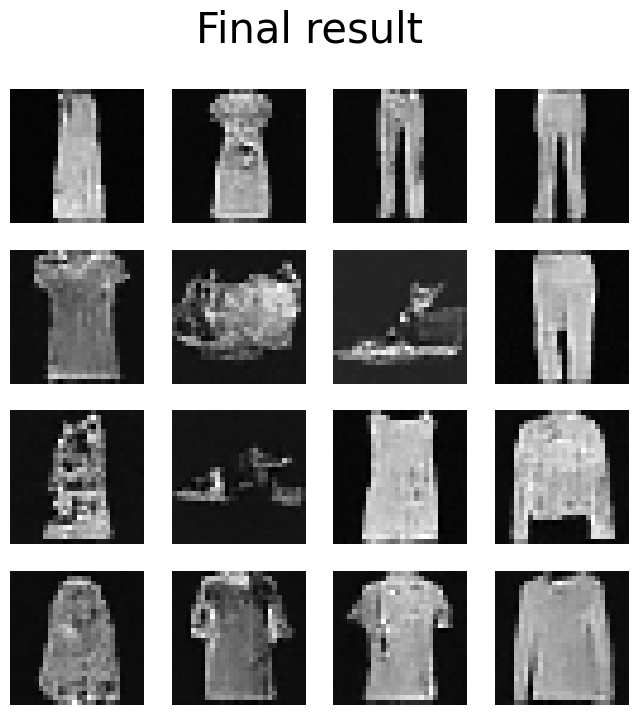

In [17]:
# Cargar pesos del modelo entrenado
best_model = DDPMModel(
    UNet(n_steps, img_size=img_shape),
    n_steps=n_steps,
    min_beta=original_min_beta,
    max_beta=original_max_beta,
    device=device,
)
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()

# Generar nuevas imágenes y presentar el resultado final
new_images = generate_output(
        best_model,
        n_samples=25,
        device=device,
        gif_name="new_images.gif",
        img_size=img_shape
    )

visualize_images(new_images[:16], "Final result")

# Trabajo individual: Exploración del impacto de los valores Beta en el desempeño del modelo DDPM

En esta fase individual del laboratorio, tu tarea será explorar cómo los valores de los parámetros `min_beta` y `max_beta` afectan el entrenamiento y el desempeño del modelo DDPM. Estos parámetros controlan la cantidad de ruido que se añade a las imágenes en diferentes etapas del proceso de difusión. El valor de `min_beta` afecta los primeros pasos del proceso de ruido, mientras que `max_beta` define el nivel de ruido en los últimos pasos.

El objetivo de esta actividad es que te familiarices con la relación entre los valores de beta y la capacidad del modelo para aprender a remover ruido de las imágenes de manera eficiente. Para ello, modificarás únicamente los valores de `min_beta` y `max_beta`, dejando el resto de los parámetros del modelo sin cambios, de modo que puedas aislar el impacto de estos valores en la calidad del modelo.

Una vez hayas completado tus experimentos, responderás a una serie de preguntas de opción múltiple que pondrán a prueba tu capacidad de análisis. Estas preguntas se centrarán en el impacto de los betas en:
- La cantidad de ruido añadido en las imágenes.
- La calidad y estabilidad del modelo durante el entrenamiento.
- La velocidad de convergencia del loss.

**Recomendaciones:**
Mantén consistencia en los demás parámetros: Asegúrate de que no cambias otros aspectos del modelo mientras experimentas con los betas. De esta manera, podrás aislar los efectos específicos de `min_beta` y `max_beta`.
Realiza múltiples pruebas: Es recomendable que realices más de un experimento, probando diferentes combinaciones de valores para observar de manera clara el efecto de los betas en el comportamiento del modelo.

**Objetivo de la actividad:**
El propósito de esta actividad es que desarrolles una comprensión profunda sobre cómo los parámetros de ruido en los modelos de difusión probabilística afectan el proceso de aprendizaje del modelo y la calidad de los resultados. Al realizar estos experimentos, podrás observar de primera mano cómo un buen ajuste de los parámetros `min_beta` y `max_beta` puede llevar a un mejor desempeño en términos de velocidad de entrenamiento y precisión del modelo.

Al finalizar esta actividad, habrás reforzado tu capacidad para ajustar hiperparámetros clave en el modelo DDPM y evaluar sus efectos de manera analítica.

# 1. Modificación de los valores de beta:

Para iniciar esta fase del laboratorio debes explorar distintos cambios en las variables `min_beta` y `max_beta` en los siguientes rangos:
* `min_beta`: [1e-6, 1e-3]
* `max_beta`: [0.005, 0.05]

Dentro de este rango, elige varios pares de valores con los que experimentar (te recomendamos primero modificar un límite a la vez y luego sí probar cambiando ambos).
Asegúrate de que estos son los únicos parámetros que cambian durante tus experimentos. El resto de los parámetros, como el número de pasos de difusión (n_steps) o el tamaño del lote, deben permanecer constantes para que las variaciones observadas en el desempeño del modelo se deban exclusivamente a los cambios en los betas.

**Pistas:** Puedes guiarte de las siguientes preguntas para realizar un análisis exhaustivo de tus experimentos.
* Observa cómo los diferentes valores de beta afectan el desempeño del modelo. ¿Los cambios en los betas permiten que el modelo aprenda a remover ruido de las imágenes más rápido? ¿Mejoran o empeoran la calidad de las imágenes generadas?
* Evalúa si el loss disminuye de manera consistente durante el entrenamiento y si el modelo alcanza un loss más bajo cuando se ajustan los betas adecuadamente.
* Puedes apoyarte también de las herramientas de visualización pre-entrenamiento y post-entrenamiento para visualizar cambios en los procesos forward y backward.

In [18]:
min_beta = 1e-4
max_beta = 0.02
print(f"min_beta = {min_beta}, original_min_beta = {original_min_beta}\nmax_beta = {max_beta}, original_max_beta = {original_max_beta}")

ddpm = DDPMModel(
    UNet(n_steps, img_size=img_shape),
    n_steps=n_steps,
    min_beta=min_beta,
    max_beta=max_beta,
    device=device,
)

print(f"Cantidad de parámetros del modelo: {sum([p.numel() for p in ddpm.parameters()])}")

# Preparar herramientas de entrenamiento
store_path = "ddpm_model.pt"
total_epochs = 100
learning_rate = 0.001
optimizer = Adam(ddpm.parameters(), learning_rate)

min_beta = 0.0001, original_min_beta = 0.0001
max_beta = 0.02, original_max_beta = 0.02
Cantidad de parámetros del modelo: 610350


### Verifica y guarda los resultados de tu respuesta 1

A continuación observa los resultados de los valores de beta escogidos y guarda tu respuesta. Recuerda que visualizar los resultados será importante posteriormente. 

Training progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: best model stored in ddpm_model.pt with loss of 0.424


Epoch 2/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: best model stored in ddpm_model.pt with loss of 0.095


...

Epoch 97/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 99: best model stored in ddpm_model.pt with loss of 0.024


Epoch 100/100:   0%|          | 0/469 [00:00<?, ?it/s]

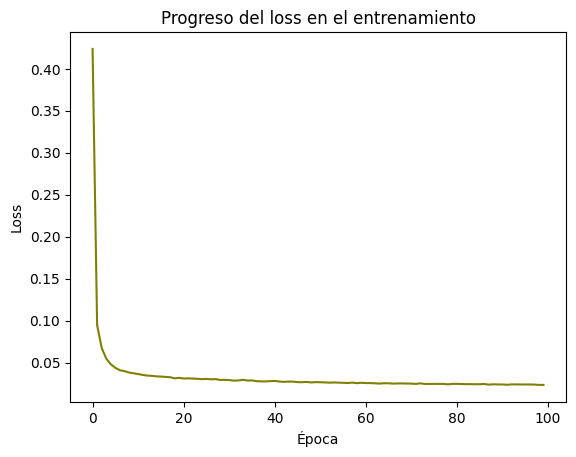

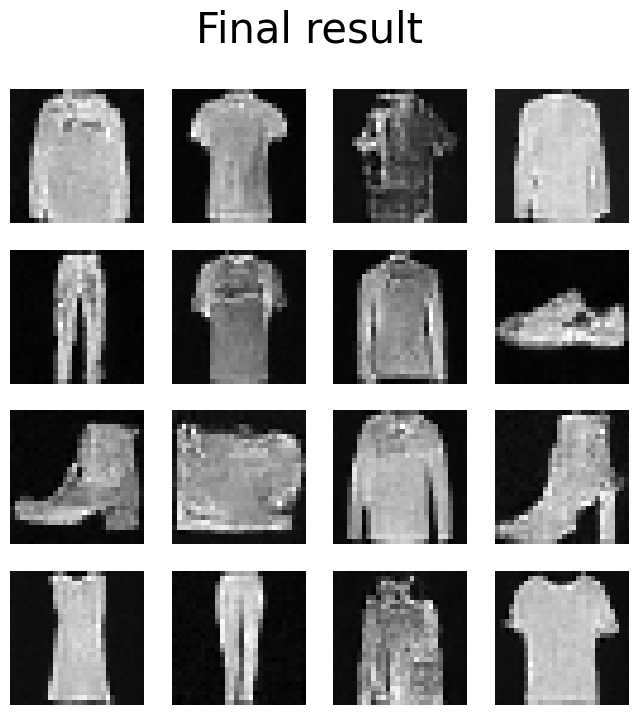

In [19]:
assert type(min_beta) == float
assert type(max_beta) == float
experiment_losses = train_model(ddpm, total_epochs, optimizer, store_path)

# Observa el desempeño de tu modelo nuevo en la generación de imágenes
# Cargar pesos del modelo entrenado
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()

# Generar nuevas imágenes y presentar el resultado final
new_images = generate_output(
        best_model,
        n_samples=25,
        device=device,
        gif_name="new_images.gif",
        img_size=img_shape
    )

visualize_images(new_images[:16], "Final result")
lm.verify_and_save(1, [min_beta, max_beta], codigo)

# 2. Selección de valores de beta para retrasar la convergencia

En esta actividad, tu objetivo será seleccionar valores de min_beta y max_beta que, **según tu análisis resultante del punto anterior**, harían que el modelo DDPM tarde más en converger. Esto significa que el loss debería disminuir más lentamente en comparación con los valores originales (min_beta = 1e-4 y max_beta = 0.02).

Entrena el modelo con los valores seleccionados de beta y guarda la lista de losses en la variable `slow_convergence_train`.

In [20]:
# Declarar modelo con nuevos Betas
# TODO: determina los valores nuevos de beta que, basado en tu análisis previo, causarán un entrenamiento más lento en converger. 
# Asigna dichos valores a las variables "new_min_beta" y "new_max_beta". 
# Recuerda no cambiar otros parámetros de entrenamiento además de los betas
new_min_beta = 1e-3
new_max_beta = 0.05


ddpm = DDPMModel(
    UNet(n_steps, img_size=img_shape),
    n_steps=n_steps,
    min_beta=new_min_beta,
    max_beta=new_max_beta,
    device=device,
)

print(f"Cantidad de parámetros del modelo: {sum([p.numel() for p in ddpm.parameters()])}")

# Preparar herramientas de entrenamiento
store_path = "slow_model.pt"
total_epochs = 100
learning_rate = 0.001
optimizer = Adam(ddpm.parameters(), learning_rate)

Cantidad de parámetros del modelo: 610350


### Verifica y guarda tu respuesta 2
A continuación entrena el modelo de convergencia más lenta y guarda tu respuesta asociada al mismo

Training progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: best model stored in slow_model.pt with loss of 0.349


Epoch 2/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: best model stored in slow_model.pt with loss of 0.092


...

Epoch 97: best model stored in slow_model.pt with loss of 0.014


Epoch 98/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 100: best model stored in slow_model.pt with loss of 0.014


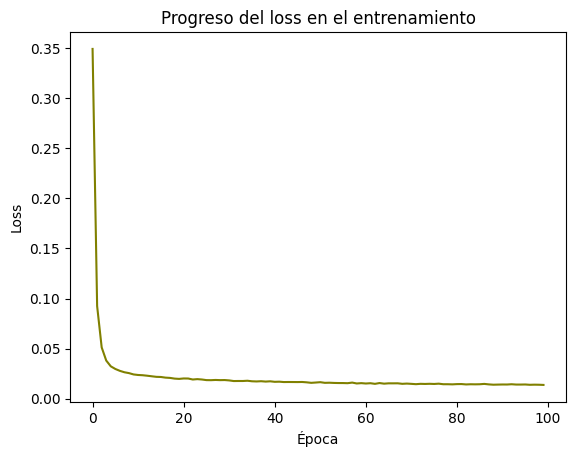

In [21]:
slow_convergence_losses = train_model(ddpm, total_epochs, optimizer, store_path)
assert len(slow_convergence_losses) == 100
lm.verify_and_save(2, [new_min_beta, new_max_beta, slow_convergence_losses], codigo)

Ahora observemos los resultados del modelo de convergencia más lenta. ¿Notas alguna diferencia?

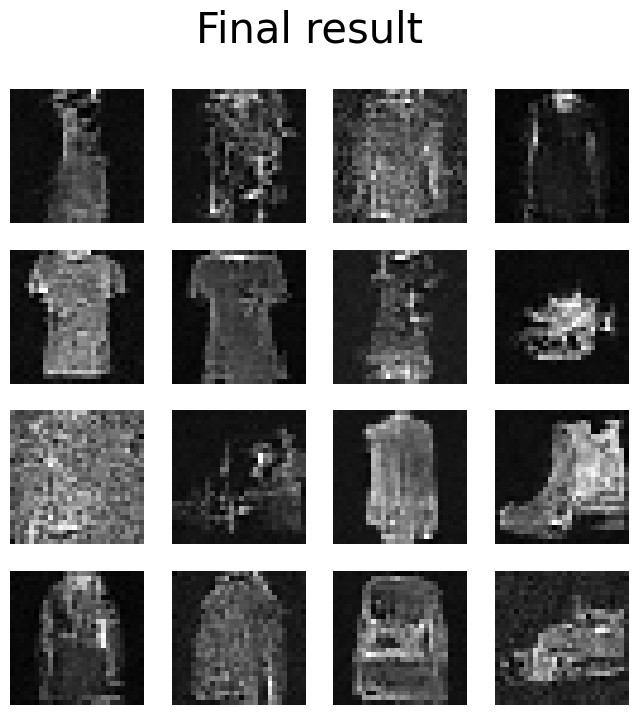

In [22]:
best_model = DDPMModel(
    UNet(n_steps, img_size=img_shape),
    n_steps=n_steps,
    min_beta=original_min_beta,
    max_beta=original_max_beta,
    device=device,
)

# Observa el desempeño de tu modelo nuevo en la generación de imágenes
# Cargar pesos del modelo entrenado
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()

# Generar nuevas imágenes y presentar el resultado final
new_images = generate_output(
        best_model,
        n_samples=25,
        device=device,
        gif_name="slow_new_images.gif",
        img_size=img_shape
    )

visualize_images(new_images[:16], "Final result")

# 3. Preguntas de Análisis
En esta sección, aplicarás lo que has aprendido sobre el impacto de los valores min_beta y max_beta en el entrenamiento y desempeño del modelo DDPM. A lo largo de los experimentos realizados, has observado cómo los cambios en estos parámetros afectan tanto la convergencia del loss como la calidad de las imágenes generadas.

Ahora, responderás una serie de preguntas que evaluarán tu comprensión sobre cómo estos valores influyen en el comportamiento del modelo. Estos dos parámetros juegan un papel crucial en la capacidad del modelo para generar imágenes a partir de ruido y en la velocidad con la que aprende a hacerlo. Por favor, selecciona la opción que mejor describa los efectos observados en tus experimentos.



Selecciona verdadero o falso para las siguientes afirmaciones:

1. **Afirmación 1:** "Un valor más alto de max_beta genera imágenes más claras."
2. **Afirmación 2:** "Un valor más bajo de min_beta disminuye el ruido en los primeros pasos."

In [23]:
# Responde asignando True o False a las variables correspondientes a cada afirmación:
afirmacion_1 = False
afirmacion_2 = True

### Verifica y guarda tu respuesta 3
En la siguiente celda verifica y guarda tus respuestas a las afirmaciones

In [24]:
assert type(afirmacion_1) == bool
assert type(afirmacion_2) == bool
lm.verify_and_save(3, [afirmacion_1, afirmacion_2], codigo)

Selecciona la respuesta correcta y asigna la letra en las variables de la celda siguiente:
1. ¿Cómo afecta un valor alto de max_beta al modelo?

a) Las imágenes generadas tendrán más ruido.

b) Las imágenes generadas serán más claras.

c) No afecta la calidad de las imágenes.

d) Mejora la estabilidad del modelo.

2. ¿Qué sucede con el **entrenamiento** y con la **generación** de imágenes cuando reduces los valores de min_beta y max_beta respecto a los valores originales?

a) El modelo añade más ruido, lo que hace que el entrenamiento sea más lento y las imágenes generadas tengan más artefactos.

b) El modelo añade menos ruido, lo que hace que el entrenamiento sea más rápido y las imágenes generadas sean más limpias, pero el modelo podría generalizar peor.

c) El modelo añade menos ruido, pero el entrenamiento se vuelve más lento porque el modelo no puede aprender a remover ruido correctamente.

d) El modelo añade más ruido, lo que hace que el entrenamiento sea más rápido y las imágenes generadas sean de mayor calidad.

In [25]:
# Responde asignando solo la letra de la respuesta correcta a la variable de cada pregunta:
pregunta_1 = "a"
pregunta_2 = "b"

### Verifica y guarda tu respuesta 4
En la siguiente celda guarda las respuestas asociadas a las preguntas de selección múltiple.

In [26]:
assert type(pregunta_1) == str and len(pregunta_1) == 1
assert type(pregunta_2) == str and len(pregunta_2) == 1
lm.verify_and_save(4, [pregunta_1, pregunta_2], codigo)

### Para finalizar
Verifica y guarda todas tus respuestas empleando la siguiente celda. Para enviar el laboratorio, usa la ventana de envío siguiendo el tutorial de la sección del laboratorio. 

In [27]:
lm.save_answers(codigo)